In [ ]:
#!/usr/bin/env python3
"""
Fit RDM (shared/varying v_error) and LBA (shared/varying v_error) to rr98,
matching the exact same no-lapse, configurable-binning, trimmed-data
convention as the DDM/SRDM fitting scripts elsewhere in this project.

OUTPUT FILES (one per model variant, all participants + N_LEVELS stacked):
  - fits_rdm_shared_verr.csv
  - fits_rdm_varying_verr.csv
  - fits_lba_shared_verr.csv
  - fits_lba_varying_verr.csv
"""

import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel

# ╔═══════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — edit these                              ║
# ╚═══════════════════════════════════════════════════════════╝
N_LEVELS      = 3      # <-- CHANGE THIS: 7, 11, 16, 33, etc. -- same
                        #     convention as the DDM/SRDM scripts. Loop
                        #     over a list of values the same way you did
                        #     for the DDM/SRDM resolution sweep.
PARTICIPANTS  = ["jf", "kr", "nh"]
TRIM_LOW      = 0.01
TRIM_HIGH     = 0.99

MODELS = {
    "rdm_free":  ("RDM_fixed_B_by_instruction.stan",  "fits_rdm_free.csv"),
}




def load_data():
    df = pd.read_csv("../rr98.csv")
    df = df[df["outlier"] == False].copy()
    df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})
    df = df[df["strength"] != 16].copy()
    df["act_correct"] = ((df["strength"] > 16) == (df["response"] == "light")).astype(int)

    if N_LEVELS == 33:
        unique_strengths = sorted(df["strength"].unique())
        strength_to_level = {s: i+1 for i, s in enumerate(unique_strengths)}
        df["diff_level"] = df["strength"].map(strength_to_level)
        actual_levels = len(unique_strengths)
    else:
        def _qcut_levels(s):
            return pd.qcut(s, q=N_LEVELS, labels=False, duplicates="drop") + 1
        df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
        actual_levels = df["diff_level"].nunique()

    df["cell"] = (df["sat_id"] - 1) * actual_levels + df["diff_level"]
    print(f"N_LEVELS requested: {N_LEVELS}, actual unique levels: {actual_levels}")
    return df, actual_levels


def trim_extremes(df, low=TRIM_LOW, high=TRIM_HIGH):
    def _trim_group(g):
        lo, hi = g["rt"].quantile([low, high])
        return g[(g["rt"] >= lo) & (g["rt"] <= hi)]
    return df.groupby(["id", "cell"], group_keys=False).apply(_trim_group)


def build_data(df,df_b, pid, n_levels):
    d = df[df["id"] == pid]
    df_b = df_b[df_b["n_levels_requested"]==7]
    B = float(df_b[df_b["pid"] == pid]["B"])
    print(B)
    d_correct = d[d["act_correct"] == 1]
    d_false = d[d["act_correct"] == 0]
    t0_hi = float(d["rt"].min())
    return {
        "N_LEVELS": n_levels,
        "N_correct": len(d_correct), "N_false": len(d_false),
        "rt_correct": d_correct["rt"].to_numpy(),
        "rt_false": d_false["rt"].to_numpy(),
        "cell_correct": d_correct["cell"].to_numpy(dtype=int),
        "cell_false": d_false["cell"].to_numpy(dtype=int),
        "t0_hi": t0_hi,
        "B":B,
    }


def get_inits(model_key, n_levels, t0_hi):

    base = {"A": 0.4, "v_correct": [2.5]*n_levels*2,"v_error": [2.5]*n_levels*2,"s_correct": [1.5]*n_levels*2,"s_error": [1.5]*n_levels*2, "t0": 0.2*t0_hi}

    return base


def n_params_for(model_key, n_levels):
    # B/k[2] + A + v_correct[N] + v_error(1 or N) + t0
    v_err_params = 1 if model_key.endswith("shared") else n_levels
    return 2 + 1 + n_levels + v_err_params + 1


def aic_bic(mle, n_params):
    p = mle.optimized_params_pd
    ll_cols = [c for c in p.columns if c.startswith("log_lik")]
    total_ll = p[ll_cols].iloc[0].sum()
    n = len(ll_cols)
    return {"n_params": n_params, "n_trials": n, "log_lik": total_ll,
            "AIC": 2*n_params - 2*total_ll, "BIC": n_params*np.log(n) - 2*total_ll}


def save_row(csv_path, pid, n_levels_requested, n_levels_actual, mle, ic, t0_hi):
    raw = mle.optimized_params_pd.iloc[0]
    keep_cols = [c for c in raw.index if not c.startswith("log_lik")]
    row = raw[keep_cols].to_dict()
    row = {"pid": pid, "n_levels_requested": n_levels_requested,
           "n_levels_actual": n_levels_actual, "n_params": ic["n_params"],
           "n_trials": ic["n_trials"], "log_lik_total": ic["log_lik"],
           "AIC": ic["AIC"], "BIC": ic["BIC"], "t0_hi": t0_hi,
           "fit_time_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
           **row}
    new_row = pd.DataFrame([row])
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        mask = (existing["pid"] == pid) & (existing["n_levels_actual"] == n_levels_actual)
        existing = existing[~mask]
        combined = pd.concat([existing, new_row], ignore_index=True, sort=False)
    else:
        combined = new_row
    combined = combined.sort_values(["n_levels_actual", "pid"]).reset_index(drop=True)
    combined.to_csv(csv_path, index=False)


def main():
    df, actual_levels = load_data()
    df = trim_extremes(df)
    df_b = pd.read_csv("/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/NoLapse/fits_srdm_nolapse.csv")

    compiled = {}
    for model_key, (stan_file, _) in MODELS.items():
        print(f"Compiling {model_key} ({stan_file})...")
        compiled[model_key] = CmdStanModel(stan_file=stan_file)

    for pid in PARTICIPANTS:
        print(f"\n{'='*60}\n  {pid}  (N_LEVELS={actual_levels})\n{'='*60}")
        data = build_data(df,df_b, pid, actual_levels)
        print(f"  N_correct={data['N_correct']}  N_false={data['N_false']}  "
              f"t0_hi={data['t0_hi']:.4f}")

        for model_key, (stan_file, out_path) in MODELS.items():
            print(f"\n  --- {model_key} ---")
            inits = get_inits(model_key, actual_levels, data["t0_hi"])
            mle = compiled[model_key].optimize(data=data, inits=inits, algorithm="lbfgs",
                                               iter=5000, show_console=False)
            n_params = n_params_for(model_key, actual_levels)
            ic = aic_bic(mle, n_params)
            save_row(out_path, pid, N_LEVELS, actual_levels, mle, ic, data["t0_hi"])
            print(f"  n_params={n_params}  LL={ic['log_lik']:.1f}  "
                  f"AIC={ic['AIC']:.1f}  BIC={ic['BIC']:.1f}")

    print("\nSaved:")
    for _, out_path in MODELS.values():
        print(f"  {out_path}")


if __name__ == "__main__":
    main()


/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/58085903.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["id", "cell"], group_keys=False).apply(_trim_group)
/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/58085903.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  B = float(df_b[df_b["pid"] == pid]["B"])
22:37:33 - cmdstanpy - INFO - Chain [1] start processing


N_LEVELS requested: 5, actual unique levels: 5
Compiling rdm_free (RDM_fixed_B_by_instruction.stan)...

  jf  (N_LEVELS=5)
3.3494201
  N_correct=6282  N_false=897  t0_hi=0.2100

  --- rdm_free ---


22:37:48 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/58085903.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  B = float(df_b[df_b["pid"] == pid]["B"])
22:37:48 - cmdstanpy - INFO - Chain [1] start processing


  n_params=14  LL=3527.2  AIC=-7026.4  BIC=-6930.1

  kr  (N_LEVELS=5)
2.0813846
  N_correct=6109  N_false=934  t0_hi=0.2080

  --- rdm_free ---


22:38:21 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/58085903.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  B = float(df_b[df_b["pid"] == pid]["B"])
22:38:21 - cmdstanpy - INFO - Chain [1] start processing


  n_params=14  LL=3488.7  AIC=-6949.4  BIC=-6853.4

  nh  (N_LEVELS=5)
2.3286051
  N_correct=7273  N_false=631  t0_hi=0.2280

  --- rdm_free ---


22:39:05 - cmdstanpy - INFO - Chain [1] done processing


  n_params=14  LL=5568.2  AIC=-11108.5  BIC=-11010.8

Saved:
  fits_rdm_free.csv


In [ ]:
#!/usr/bin/env python3
"""
Fit RDM (shared/varying v_error) and LBA (shared/varying v_error) to rr98,
matching the exact same no-lapse, configurable-binning, trimmed-data
convention as the DDM/SRDM fitting scripts elsewhere in this project.

OUTPUT FILES (one per model variant, all participants + N_LEVELS stacked):
  - fits_rdm_shared_verr.csv
  - fits_rdm_varying_verr.csv
  - fits_lba_shared_verr.csv
  - fits_lba_varying_verr.csv
"""

import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel

# ╔═══════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — edit these                              ║
# ╚═══════════════════════════════════════════════════════════╝
N_LEVELS      = 5      # <-- CHANGE THIS: 7, 11, 16, 33, etc. -- same
                        #     convention as the DDM/SRDM scripts. Loop
                        #     over a list of values the same way you did
                        #     for the DDM/SRDM resolution sweep.
PARTICIPANTS  = ["jf", "kr", "nh"]
TRIM_LOW      = 0.01
TRIM_HIGH     = 0.99

MODELS = {
    "rdm_free":  ("RDM_fixed_B_noA.stan",  "fits_rdm_free_noA.csv"),
}




def load_data():
    df = pd.read_csv("../rr98.csv")
    df = df[df["outlier"] == False].copy()
    df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})
    df = df[df["strength"] != 16].copy()
    df["act_correct"] = ((df["strength"] > 16) == (df["response"] == "light")).astype(int)

    if N_LEVELS == 33:
        unique_strengths = sorted(df["strength"].unique())
        strength_to_level = {s: i+1 for i, s in enumerate(unique_strengths)}
        df["diff_level"] = df["strength"].map(strength_to_level)
        actual_levels = len(unique_strengths)
    else:
        def _qcut_levels(s):
            return pd.qcut(s, q=N_LEVELS, labels=False, duplicates="drop") + 1
        df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
        actual_levels = df["diff_level"].nunique()

    df["cell"] = (df["sat_id"] - 1) * actual_levels + df["diff_level"]
    print(f"N_LEVELS requested: {N_LEVELS}, actual unique levels: {actual_levels}")
    return df, actual_levels


def trim_extremes(df, low=TRIM_LOW, high=TRIM_HIGH):
    def _trim_group(g):
        lo, hi = g["rt"].quantile([low, high])
        return g[(g["rt"] >= lo) & (g["rt"] <= hi)]
    return df.groupby(["id", "cell"], group_keys=False).apply(_trim_group)


def build_data(df,df_b, pid, n_levels):
    d = df[df["id"] == pid]
    df_b = df_b[df_b["n_levels_requested"]==7]
    B = float(df_b[df_b["pid"] == pid]["B"])
    print(B)
    d_correct = d[d["act_correct"] == 1]
    d_false = d[d["act_correct"] == 0]
    t0_hi = float(d["rt"].min())
    return {
        "N_LEVELS": n_levels,
        "N_correct": len(d_correct), "N_false": len(d_false),
        "rt_correct": d_correct["rt"].to_numpy(),
        "rt_false": d_false["rt"].to_numpy(),
        "cell_correct": d_correct["cell"].to_numpy(dtype=int),
        "cell_false": d_false["cell"].to_numpy(dtype=int),
        "t0_hi": t0_hi,
        "B":B,
    }


def get_inits(model_key, n_levels, t0_hi):

    base = {"v_correct": [2.5]*n_levels*2,"v_error": [2.5]*n_levels*2,"s_correct": [1.5]*n_levels*2,"s_error": [1.5]*n_levels*2, "t0": 0.2*t0_hi}

    return base


def n_params_for(model_key, n_levels):
    # B/k[2] + A + v_correct[N] + v_error(1 or N) + t0
    v_err_params = 1 if model_key.endswith("shared") else n_levels
    return 2 + 1 + n_levels + v_err_params + 1


def aic_bic(mle, n_params):
    p = mle.optimized_params_pd
    ll_cols = [c for c in p.columns if c.startswith("log_lik")]
    total_ll = p[ll_cols].iloc[0].sum()
    n = len(ll_cols)
    return {"n_params": n_params, "n_trials": n, "log_lik": total_ll,
            "AIC": 2*n_params - 2*total_ll, "BIC": n_params*np.log(n) - 2*total_ll}


def save_row(csv_path, pid, n_levels_requested, n_levels_actual, mle, ic, t0_hi):
    raw = mle.optimized_params_pd.iloc[0]
    keep_cols = [c for c in raw.index if not c.startswith("log_lik")]
    row = raw[keep_cols].to_dict()
    row = {"pid": pid, "n_levels_requested": n_levels_requested,
           "n_levels_actual": n_levels_actual, "n_params": ic["n_params"],
           "n_trials": ic["n_trials"], "log_lik_total": ic["log_lik"],
           "AIC": ic["AIC"], "BIC": ic["BIC"], "t0_hi": t0_hi,
           "fit_time_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
           **row}
    new_row = pd.DataFrame([row])
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        mask = (existing["pid"] == pid) & (existing["n_levels_actual"] == n_levels_actual)
        existing = existing[~mask]
        combined = pd.concat([existing, new_row], ignore_index=True, sort=False)
    else:
        combined = new_row
    combined = combined.sort_values(["n_levels_actual", "pid"]).reset_index(drop=True)
    combined.to_csv(csv_path, index=False)


def main():
    df, actual_levels = load_data()
    df = trim_extremes(df)
    df_b = pd.read_csv("/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/NoLapse/fits_srdm_nolapse.csv")

    compiled = {}
    for model_key, (stan_file, _) in MODELS.items():
        print(f"Compiling {model_key} ({stan_file})...")
        compiled[model_key] = CmdStanModel(stan_file=stan_file)

    for pid in PARTICIPANTS:
        print(f"\n{'='*60}\n  {pid}  (N_LEVELS={actual_levels})\n{'='*60}")
        data = build_data(df,df_b, pid, actual_levels)
        print(f"  N_correct={data['N_correct']}  N_false={data['N_false']}  "
              )

        for model_key, (stan_file, out_path) in MODELS.items():
            print(f"\n  --- {model_key} ---")
            inits = get_inits(model_key, actual_levels, data["t0_hi"])
            mle = compiled[model_key].optimize(data=data, inits=inits, algorithm="lbfgs",
                                               iter=5000, show_console=False)
            n_params = n_params_for(model_key, actual_levels)
            ic = aic_bic(mle, n_params)
            save_row(out_path, pid, N_LEVELS, actual_levels, mle, ic, data["t0_hi"])
            print(f"  n_params={n_params}  LL={ic['log_lik']:.1f}  "
                  f"AIC={ic['AIC']:.1f}  BIC={ic['BIC']:.1f}")

    print("\nSaved:")
    for _, out_path in MODELS.values():
        print(f"  {out_path}")


if __name__ == "__main__":
    main()


/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/3988462523.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["id", "cell"], group_keys=False).apply(_trim_group)
22:39:05 - cmdstanpy - INFO - compiling stan file /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/LBA_RDM/RDM_fixed_B_noA.stan to exe file /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/LBA_RDM/RDM_fixed_B_noA


N_LEVELS requested: 5, actual unique levels: 5
Compiling rdm_free (RDM_fixed_B_noA.stan)...


22:39:17 - cmdstanpy - INFO - compiled model executable: /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/LBA_RDM/RDM_fixed_B_noA
/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/3988462523.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  B = float(df_b[df_b["pid"] == pid]["B"])
22:39:17 - cmdstanpy - INFO - Chain [1] start processing



  jf  (N_LEVELS=5)
3.3494201
  N_correct=6282  N_false=897  t0_hi=0.2100

  --- rdm_free ---


22:39:18 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/3988462523.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  B = float(df_b[df_b["pid"] == pid]["B"])
22:39:18 - cmdstanpy - INFO - Chain [1] start processing


  n_params=14  LL=3507.3  AIC=-6986.7  BIC=-6890.3

  kr  (N_LEVELS=5)
2.0813846
  N_correct=6109  N_false=934  t0_hi=0.2080

  --- rdm_free ---


22:39:19 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/3988462523.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  B = float(df_b[df_b["pid"] == pid]["B"])
22:39:19 - cmdstanpy - INFO - Chain [1] start processing


  n_params=14  LL=3480.8  AIC=-6933.7  BIC=-6837.6

  nh  (N_LEVELS=5)
2.3286051
  N_correct=7273  N_false=631  t0_hi=0.2280

  --- rdm_free ---


22:39:20 - cmdstanpy - INFO - Chain [1] done processing


  n_params=14  LL=5555.2  AIC=-11082.5  BIC=-10984.8

Saved:
  fits_rdm_free_noA.csv


In [ ]:
df2 = pd.read_csv("fits_rdm_free.csv")
df2[df2.columns[11:30]]


,A,v_correct[1],v_correct[2],v_correct[3],v_correct[4],v_correct[5],v_correct[6],v_correct[7],v_error[1],v_error[2],v_error[3],v_error[4],v_error[5],v_error[6],v_error[7],s_correct[1],s_correct[2],s_correct[3],s_correct[4]
0,0.967991,7.000648,6.662081,5.999008,5.582118,6.241330,6.547283,6.654275,0.000277,0.000457,1.764934,3.174316,0.001040,0.000126,0.000289,2.365399,2.485449,2.819269,3.039310
1,0.000251,5.559040,4.913778,4.004584,3.964412,4.814112,5.378655,5.872687,0.000017,0.000017,1.298480,1.995588,0.000023,0.000007,0.000090,1.690988,2.168068,2.576180,2.580422
2,0.294964,6.323948,5.966979,5.116181,4.755685,5.670857,6.062938,6.168624,0.001625,0.000335,0.888713,2.237195,0.001464,0.001268,0.002370,1.581020,1.757448,1.960364,2.149635


In [21]:
df2[df2.columns[30:45]]

,s_correct[5],s_correct[6],s_correct[7],s_error[1],s_error[2],s_error[3],s_error[4],s_error[5],s_error[6],s_error[7],t0,v_correct_full[1],v_correct_full[2],v_correct_full[3],v_correct_full[4]
0,2.717177,2.496359,2.396124,3.757538,3.844364,3.969283,3.822301,5.246484,4.818672,4.498506,3.203326e-07,7.000648,6.662081,5.999008,5.582118
1,2.179672,1.866157,1.465113,3.080151,3.463722,3.598900,3.216564,3.534507,3.289328,3.413428,1.616459e-04,5.559040,4.913778,4.004584,3.964412
2,1.775500,1.535937,1.514163,2.467573,2.907821,3.272804,2.700474,3.272011,3.316858,3.106797,3.361115e-02,6.323948,5.966979,5.116181,4.755685


In [54]:
# %% [markdown]
# # Compare RDM (free v/s per cell) against SRDM-implied v/s
#
# The SRDM's own generative structure already computes something
# equivalent to "v" and "s" (noise) internally, via its signal-detection
# front end: given d' and c per (difficulty x instruction) cell and a
# shared spike rate r, it derives
#     pk = Phi(d/2 - c),   pf = Phi(-d/2 - c)
#     vk = pk * r,         vf = pf * r
#     sigma_k = sqrt(pk*(1-pk)*r),   sigma_f = sqrt(pf*(1-pf)*r)
# (with a 0.05 floor on the sigmas, matching the Stan model).
#
# vk/sigma_k are the SRDM's implied "own-accumulator" drift/noise (i.e.
# the correct-accumulator analog), vf/sigma_f the "other-accumulator"
# (error-accumulator analog) -- directly comparable to RDM_free's own
# v_correct/s_correct and v_error/s_error, cell for cell, since both
# fits used the same N_LEVELS=7 binning and the same cell indexing
# convention (cell = (sat_id-1)*N_LEVELS + diff_level).
#
# NOTE: the n_params stored in fits_rdm_free.csv is wrong (stale formula
# left over from an earlier model version -- it undercounts by a lot).
# The correct count for RDM_free is 4*N_CELLS + 2 (v_correct, v_error,
# s_correct, s_error, each sized N_CELLS, plus A and t0). This notebook
# recomputes AIC/BIC using the correct count rather than trusting the CSV.

# %%
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

RDM_PATH = "fits_rdm_free_noA.csv"
SRDM_PATH = "/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/NoLapse/fits_srdm_nolapse.csv"
N_LEVELS = 3            # resolution the RDM_free fit used
N_CELLS = 2 * N_LEVELS

PARTICIPANTS = ["jf", "kr", "nh"]
COLORS = {"jf": "tab:blue", "kr": "tab:orange", "nh": "tab:green"}

rdm = pd.read_csv(RDM_PATH).set_index("pid")
srdm_all = pd.read_csv(SRDM_PATH)
srdm = srdm_all[srdm_all["n_levels_actual"] == N_LEVELS].set_index("pid")

# %% [markdown]
# ## Fix AIC/BIC for RDM_free (the stored n_params is wrong)

# %%
def recompute_aic_bic(log_lik, n_trials, n_params):
    aic = 2 * n_params - 2 * log_lik
    bic = n_params * np.log(n_trials) - 2 * log_lik
    return aic, bic

RDM_N_PARAMS_CORRECT = 4 * N_CELLS + 2  # v_correct, v_error, s_correct, s_error (each N_CELLS) + A + t0

rows = []
for pid in PARTICIPANTS:
    r = rdm.loc[pid]
    aic_fixed, bic_fixed = recompute_aic_bic(r["log_lik_total"], r["n_trials"], RDM_N_PARAMS_CORRECT)
    rows.append(dict(
        pid=pid,
        n_params_stored=r["n_params"], n_params_correct=RDM_N_PARAMS_CORRECT,
        log_lik_RDM=r["log_lik_total"],
        AIC_RDM_stored=r["AIC"], AIC_RDM_correct=aic_fixed,
        BIC_RDM_stored=r["BIC"], BIC_RDM_correct=bic_fixed,
    ))
rdm_ic_fix = pd.DataFrame(rows).set_index("pid")
print(rdm_ic_fix)

# %% [markdown]
# ## Compute SRDM-implied v/s per (difficulty x instruction) cell

# %%
def srdm_implied_v_s(srdm_row, n_levels):
    """Returns (vk, vf, sigma_k, sigma_f) each length N_CELLS=2*n_levels,
    matching the SRDM Stan model's own transformed-parameters formulas."""
    n_cells = 2 * n_levels
    d_full = np.array([srdm_row[f"d_base[{ (i % n_levels) + 1 }]"] for i in range(n_cells)])
    c_by_sat = [srdm_row["c[1]"], srdm_row["c[2]"]]
    c_full = np.array([c_by_sat[0] if i < n_levels else c_by_sat[1] for i in range(n_cells)])
    r = srdm_row["r"]

    pk = norm.cdf(d_full/2 - c_full)
    pf = norm.cdf(-d_full/2 - c_full)
    vk = pk * r
    vf = pf * r
    sigma_k = np.maximum(np.sqrt(pk * (1-pk) * r), 0.05)
    sigma_f = np.maximum(np.sqrt(pf * (1-pf) * r), 0.05)
    return vk, vf, sigma_k, sigma_f

# %% [markdown]
# ## Build a long comparison table: one row per (pid, cell, accumulator type)

# %%
records = []
for pid in PARTICIPANTS:
    vk, vf, sigma_k, sigma_f = srdm_implied_v_s(srdm.loc[pid], N_LEVELS)
    r_row = rdm.loc[pid]

    v_correct_rdm = np.array([r_row[f"v_correct[{i}]"] for i in range(1, N_CELLS+1)])
    v_error_rdm   = np.array([r_row[f"v_error[{i}]"]   for i in range(1, N_CELLS+1)])
    s_correct_rdm = np.array([r_row[f"s_correct[{i}]"] for i in range(1, N_CELLS+1)])
    s_error_rdm   = np.array([r_row[f"s_error[{i}]"]   for i in range(1, N_CELLS+1)])

    for cell in range(N_CELLS):
        sat = "speed" if cell < N_LEVELS else "accuracy"
        level = (cell % N_LEVELS) + 1
        records.append(dict(pid=pid, cell=cell+1, sat=sat, level=level, accum="correct",
                             v_srdm=vk[cell], v_rdm=v_correct_rdm[cell],
                             s_srdm=sigma_k[cell], s_rdm=s_correct_rdm[cell]))
        records.append(dict(pid=pid, cell=cell+1, sat=sat, level=level, accum="error",
                             v_srdm=vf[cell], v_rdm=v_error_rdm[cell],
                             s_srdm=sigma_f[cell], s_rdm=s_error_rdm[cell]))

comp = pd.DataFrame(records)
comp["ratio_srdm"] = comp["v_srdm"] / comp["s_srdm"]
comp["ratio_rdm"] = comp["v_rdm"] / comp["s_rdm"]
comp.to_csv("rdm_vs_srdm_implied.csv", index=False)
comp.head(10)

# %% [markdown]
# ## Scatter: v (SRDM-implied vs. RDM freely-fitted)

# %%
fig, ax = plt.subplots(figsize=(6, 6))
markers = {"correct": "o", "error": "^"}
for pid in PARTICIPANTS:
    for accum in ["correct", "error"]:
        sub = comp[(comp.pid == pid) & (comp.accum == accum)]
        ax.scatter(sub["v_srdm"], sub["v_rdm"], color=COLORS[pid], marker=markers[accum],
                   alpha=0.8, label=f"{pid} ({accum})")
lims = [0, max(comp["v_srdm"].max(), comp["v_rdm"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("v implied from SRDM (d', c, r)")
ax.set_ylabel("v freely fitted in RDM_free")
ax.set_title("Drift rate: SRDM-implied vs. RDM freely-fitted")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("v_srdm_vs_rdm.png", dpi=150)
plt.show()

# %% [markdown]
# ## Scatter: s / noise (SRDM-implied vs. RDM freely-fitted)

# %%
fig, ax = plt.subplots(figsize=(6, 6))
for pid in PARTICIPANTS:
    for accum in ["correct", "error"]:
        sub = comp[(comp.pid == pid) & (comp.accum == accum)]
        ax.scatter(sub["s_srdm"], sub["s_rdm"], color=COLORS[pid], marker=markers[accum],
                   alpha=0.8, label=f"{pid} ({accum})")
lims = [0, max(comp["s_srdm"].max(), comp["s_rdm"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("s (noise) implied from SRDM")
ax.set_ylabel("s freely fitted in RDM_free")
ax.set_title("Noise: SRDM-implied vs. RDM freely-fitted")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("s_srdm_vs_rdm.png", dpi=150)
plt.show()

# %% [markdown]
# ## Scatter: v/s ratio (SRDM-implied vs. RDM freely-fitted)

# %%
fig, ax = plt.subplots(figsize=(6, 6))
for pid in PARTICIPANTS:
    for accum in ["correct", "error"]:
        sub = comp[(comp.pid == pid) & (comp.accum == accum)]
        ax.scatter(sub["ratio_srdm"], sub["ratio_rdm"], color=COLORS[pid], marker=markers[accum],
                   alpha=0.8, label=f"{pid} ({accum})")
lims = [0, max(comp["ratio_srdm"].max(), comp["ratio_rdm"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("v/s implied from SRDM")
ax.set_ylabel("v/s freely fitted in RDM_free")
ax.set_title("Signal-to-noise ratio (v/s): SRDM-implied vs. RDM freely-fitted")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("ratio_srdm_vs_rdm.png", dpi=150)
plt.show()

# %% [markdown]
# ## Other parameters: A, t0 (RDM) vs. B, t0, r (SRDM) -- not 1:1 comparable,
# shown side by side per participant for context rather than scatter (they
# aren't measuring the same underlying quantity, so a y=x comparison would
# be misleading).

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

t0_rdm = [rdm.loc[p, "t0"] for p in PARTICIPANTS]
t0_srdm = [srdm.loc[p, "t0"] for p in PARTICIPANTS]
x = np.arange(len(PARTICIPANTS))
axes[0].bar(x - 0.2, t0_rdm, 0.4, label="RDM_free")
axes[0].bar(x + 0.2, t0_srdm, 0.4, label="SRDM")
axes[0].set_xticks(x); axes[0].set_xticklabels(PARTICIPANTS)
axes[0].set_title("t0 (non-decision time)")
axes[0].legend(fontsize=8)

axes[1].set_xticks(x); axes[1].set_xticklabels(PARTICIPANTS)
axes[1].set_title("A (RDM starting-point range)")

axes[2].bar(x - 0.2, [srdm.loc[p, "B"] for p in PARTICIPANTS], 0.4, label="B (fixed, from SRDM)")
axes[2].bar(x + 0.2, [srdm.loc[p, "r"] for p in PARTICIPANTS], 0.4, label="r (SRDM spike rate)")
axes[2].set_xticks(x); axes[2].set_xticklabels(PARTICIPANTS)
axes[2].set_title("SRDM: B and r")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("other_params.png", dpi=150)
plt.show()

# %% [markdown]
# ## AIC / BIC comparison (using the corrected RDM_free parameter count)

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(PARTICIPANTS))
w = 0.35

aic_rdm = [rdm_ic_fix.loc[p, "AIC_RDM_correct"] for p in PARTICIPANTS]
aic_srdm = [srdm.loc[p, "AIC"] for p in PARTICIPANTS]
axes[0].bar(x - w/2, aic_rdm, w, label="RDM_free (corrected n_params)")
axes[0].bar(x + w/2, aic_srdm, w, label="SRDM")
axes[0].set_xticks(x); axes[0].set_xticklabels(PARTICIPANTS)
axes[0].set_title("AIC (lower = better)")
axes[0].legend(fontsize=8)

bic_rdm = [rdm_ic_fix.loc[p, "BIC_RDM_correct"] for p in PARTICIPANTS]
bic_srdm = [srdm.loc[p, "BIC"] for p in PARTICIPANTS]
axes[1].bar(x - w/2, bic_rdm, w, label="RDM_free (corrected n_params)")
axes[1].bar(x + w/2, bic_srdm, w, label="SRDM")
axes[1].set_xticks(x); axes[1].set_xticklabels(PARTICIPANTS)
axes[1].set_title("BIC (lower = better)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("aic_bic_comparison.png", dpi=150)
plt.show()

print("\nSummary (corrected):")
summary = pd.DataFrame({
    "pid": PARTICIPANTS,
    "n_params_RDM_free": RDM_N_PARAMS_CORRECT,
    "AIC_RDM_free": aic_rdm, "AIC_SRDM": aic_srdm,
    "dAIC (RDM-SRDM)": np.array(aic_rdm) - np.array(aic_srdm),
    "BIC_RDM_free": bic_rdm, "BIC_SRDM": bic_srdm,
    "dBIC (RDM-SRDM)": np.array(bic_rdm) - np.array(bic_srdm),
})
print(summary.to_string(index=False))

     n_params_stored  n_params_correct  log_lik_RDM  AIC_RDM_stored  \
pid                                                                   
jf                14                26  3507.326518    -6986.653036   
kr                14                26  3480.836234    -6933.672469   
nh                14                26  5555.227017   -11082.454034   

     AIC_RDM_correct  BIC_RDM_stored  BIC_RDM_correct  
pid                                                    
jf      -6962.653036    -6890.348221     -6783.801237  
kr      -6909.672469    -6837.635416     -6731.317942  
nh     -11058.454034   -10984.802294    -10877.100803  


KeyError: 'jf'

In [60]:
#!/usr/bin/env python3
"""
Fit RDM (shared/varying v_error) and LBA (shared/varying v_error) to rr98,
matching the exact same no-lapse, configurable-binning, trimmed-data
convention as the DDM/SRDM fitting scripts elsewhere in this project.

OUTPUT FILES (one per model variant, all participants + N_LEVELS stacked):
  - fits_rdm_shared_verr.csv
  - fits_rdm_varying_verr.csv
  - fits_lba_shared_verr.csv
  - fits_lba_varying_verr.csv
"""

import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel

# ╔═══════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — edit these                              ║
# ╚═══════════════════════════════════════════════════════════╝
N_LEVELS      = 5      # <-- CHANGE THIS: 7, 11, 16, 33, etc. -- same
                        #     convention as the DDM/SRDM scripts. Loop
                        #     over a list of values the same way you did
                        #     for the DDM/SRDM resolution sweep.
PARTICIPANTS  = ["jf", "kr", "nh"]
TRIM_LOW      = 0.01
TRIM_HIGH     = 0.99

MODELS = {
    "rdm_free":  ("RDM_fixed_B_t0_noA.stan",  "fits_rdm_free_t0_noA.csv"),
}




def load_data():
    df = pd.read_csv("../rr98.csv")
    df = df[df["outlier"] == False].copy()
    df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})
    df = df[df["strength"] != 16].copy()
    df["act_correct"] = ((df["strength"] > 16) == (df["response"] == "light")).astype(int)

    if N_LEVELS == 33:
        unique_strengths = sorted(df["strength"].unique())
        strength_to_level = {s: i+1 for i, s in enumerate(unique_strengths)}
        df["diff_level"] = df["strength"].map(strength_to_level)
        actual_levels = len(unique_strengths)
    else:
        def _qcut_levels(s):
            return pd.qcut(s, q=N_LEVELS, labels=False, duplicates="drop") + 1
        df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
        actual_levels = df["diff_level"].nunique()

    df["cell"] = (df["sat_id"] - 1) * actual_levels + df["diff_level"]
    print(f"N_LEVELS requested: {N_LEVELS}, actual unique levels: {actual_levels}")
    return df, actual_levels


def trim_extremes(df, low=TRIM_LOW, high=TRIM_HIGH):
    def _trim_group(g):
        lo, hi = g["rt"].quantile([low, high])
        return g[(g["rt"] >= lo) & (g["rt"] <= hi)]
    return df.groupby(["id", "cell"], group_keys=False).apply(_trim_group)


def build_data(df, df_b, pid, n_levels):
    d = df[df["id"] == pid]
    df_b_pid = df_b[(df_b["n_levels_requested"] == n_levels) & (df_b["pid"] == pid)].iloc[0]
    B = float(df_b_pid["B"])
    t0_fixed = float(df_b_pid["t0"])   # <-- NEW

    d_correct = d[d["act_correct"] == 1]
    d_false = d[d["act_correct"] == 0]
    return {
        "N_LEVELS": n_levels,
        "N_correct": len(d_correct), "N_false": len(d_false),
        "rt_correct": d_correct["rt"].to_numpy(),
        "rt_false": d_false["rt"].to_numpy(),
        "cell_correct": d_correct["cell"].to_numpy(dtype=int),
        "cell_false": d_false["cell"].to_numpy(dtype=int),
        "B": B, "t0": t0_fixed,   # t0_hi no longer needed -- no free t0 to bound
    }

def get_inits(model_key, n_levels, t0_hi=None):
    N_CELLS = 2 * n_levels
    return {
        "v_correct": [2.5]*N_CELLS, "v_error": [1.0]*N_CELLS,
        "s_correct": [1.0]*N_CELLS, "s_error": [1.0]*N_CELLS,
    }

def n_params_for(model_key, n_levels):
    N_CELLS = 2 * n_levels
    return 4 * N_CELLS   # only v_correct, v_error, s_correct, s_error -- B and t0 both fixed


def aic_bic(mle, n_params):
    p = mle.optimized_params_pd
    ll_cols = [c for c in p.columns if c.startswith("log_lik")]
    total_ll = p[ll_cols].iloc[0].sum()
    n = len(ll_cols)
    return {"n_params": n_params, "n_trials": n, "log_lik": total_ll,
            "AIC": 2*n_params - 2*total_ll, "BIC": n_params*np.log(n) - 2*total_ll}


def save_row(csv_path, pid, n_levels_requested, n_levels_actual, mle, ic):
    raw = mle.optimized_params_pd.iloc[0]
    keep_cols = [c for c in raw.index if not c.startswith("log_lik")]
    row = raw[keep_cols].to_dict()
    row = {"pid": pid, "n_levels_requested": n_levels_requested,
           "n_levels_actual": n_levels_actual, "n_params": ic["n_params"],
           "n_trials": ic["n_trials"], "log_lik_total": ic["log_lik"],
           "AIC": ic["AIC"], "BIC": ic["BIC"],
           "fit_time_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
           **row}
    new_row = pd.DataFrame([row])
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        mask = (existing["pid"] == pid) & (existing["n_levels_actual"] == n_levels_actual)
        existing = existing[~mask]
        combined = pd.concat([existing, new_row], ignore_index=True, sort=False)
    else:
        combined = new_row
    combined = combined.sort_values(["n_levels_actual", "pid"]).reset_index(drop=True)
    combined.to_csv(csv_path, index=False)


def main():
    df, actual_levels = load_data()
    df = trim_extremes(df)
    df_b = pd.read_csv("/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/NoLapse/fits_srdm_nolapse.csv")

    compiled = {}
    for model_key, (stan_file, _) in MODELS.items():
        print(f"Compiling {model_key} ({stan_file})...")
        compiled[model_key] = CmdStanModel(stan_file=stan_file)

    for pid in PARTICIPANTS:
        print(f"\n{'='*60}\n  {pid}  (N_LEVELS={actual_levels})\n{'='*60}")
        data = build_data(df,df_b, pid, actual_levels)
        print(f"  N_correct={data['N_correct']}  N_false={data['N_false']}  "
              )

        for model_key, (stan_file, out_path) in MODELS.items():
            print(f"\n  --- {model_key} ---")
            inits = get_inits(model_key, actual_levels)
            mle = compiled[model_key].optimize(data=data, inits=inits, algorithm="lbfgs",
                                               iter=5000, show_console=False)
            n_params = n_params_for(model_key, actual_levels)
            ic = aic_bic(mle, n_params)
            save_row(out_path, pid, N_LEVELS, actual_levels, mle, ic)
            print(f"  n_params={n_params}  LL={ic['log_lik']:.1f}  "
                  f"AIC={ic['AIC']:.1f}  BIC={ic['BIC']:.1f}")

    print("\nSaved:")
    for _, out_path in MODELS.values():
        print(f"  {out_path}")


if __name__ == "__main__":
    main()


/var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/ipykernel_18904/1549070959.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["id", "cell"], group_keys=False).apply(_trim_group)
09:57:11 - cmdstanpy - INFO - Chain [1] start processing


N_LEVELS requested: 5, actual unique levels: 5
Compiling rdm_free (RDM_fixed_B_t0_noA.stan)...

  jf  (N_LEVELS=5)
  N_correct=6282  N_false=897  

  --- rdm_free ---


09:57:12 - cmdstanpy - INFO - Chain [1] done processing
09:57:12 - cmdstanpy - INFO - Chain [1] start processing


  n_params=40  LL=3552.1  AIC=-7024.3  BIC=-6749.1

  kr  (N_LEVELS=5)
  N_correct=6109  N_false=934  

  --- rdm_free ---


09:57:13 - cmdstanpy - INFO - Chain [1] done processing
09:57:13 - cmdstanpy - INFO - Chain [1] start processing


  n_params=40  LL=3499.8  AIC=-6919.6  BIC=-6645.2

  nh  (N_LEVELS=5)
  N_correct=7273  N_false=631  

  --- rdm_free ---


09:57:14 - cmdstanpy - INFO - Chain [1] done processing


  n_params=40  LL=5566.9  AIC=-11053.7  BIC=-10774.7

Saved:
  fits_rdm_free_t0_noA.csv


     n_params_stored  n_params_correct  log_lik_RDM  AIC_RDM_stored  \
pid                                                                   
jf                40                40  3552.132214    -7024.264429   
kr                40                40  3499.818873    -6919.637746   
nh                40                40  5566.864782   -11053.729564   

     AIC_RDM_correct  BIC_RDM_stored  BIC_RDM_correct  
pid                                                    
jf      -7024.264429    -6749.107814     -6749.107814  
kr      -6919.637746    -6645.246166     -6645.246166  
nh     -11053.729564   -10774.724594    -10774.724594  


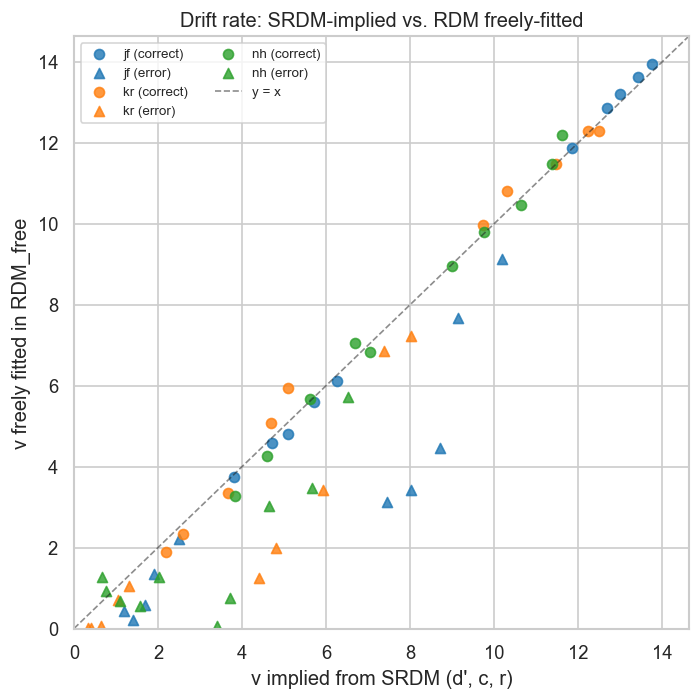

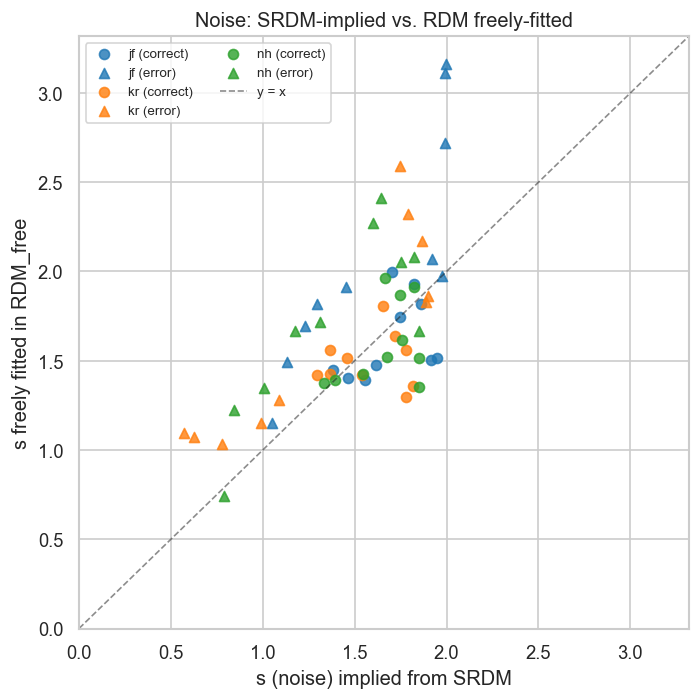

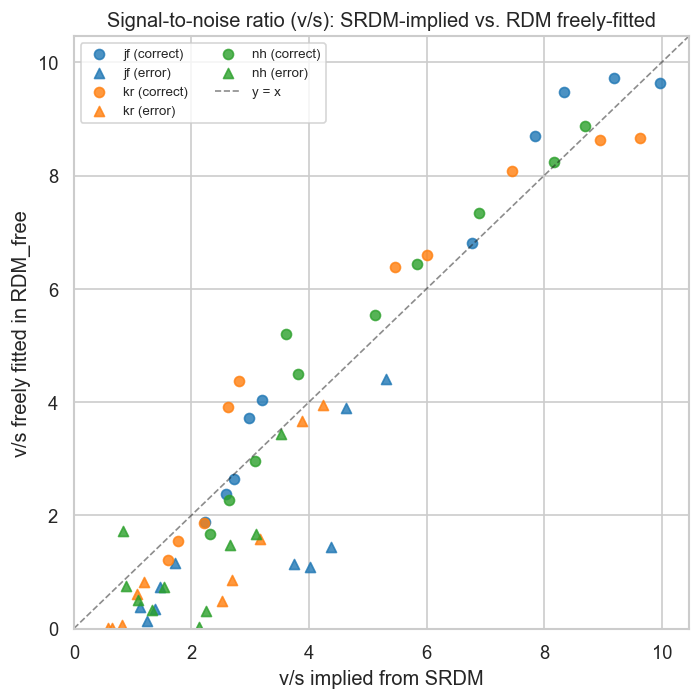

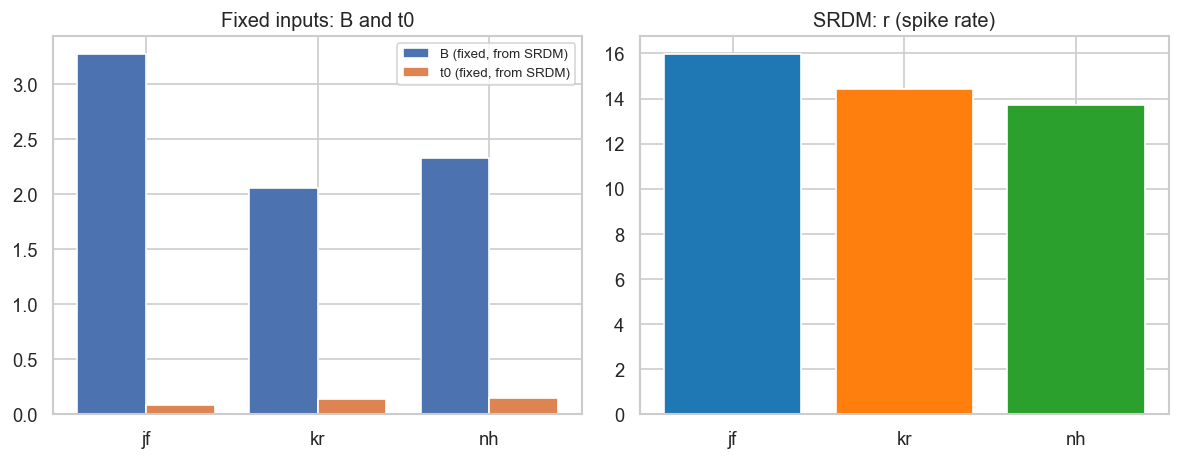

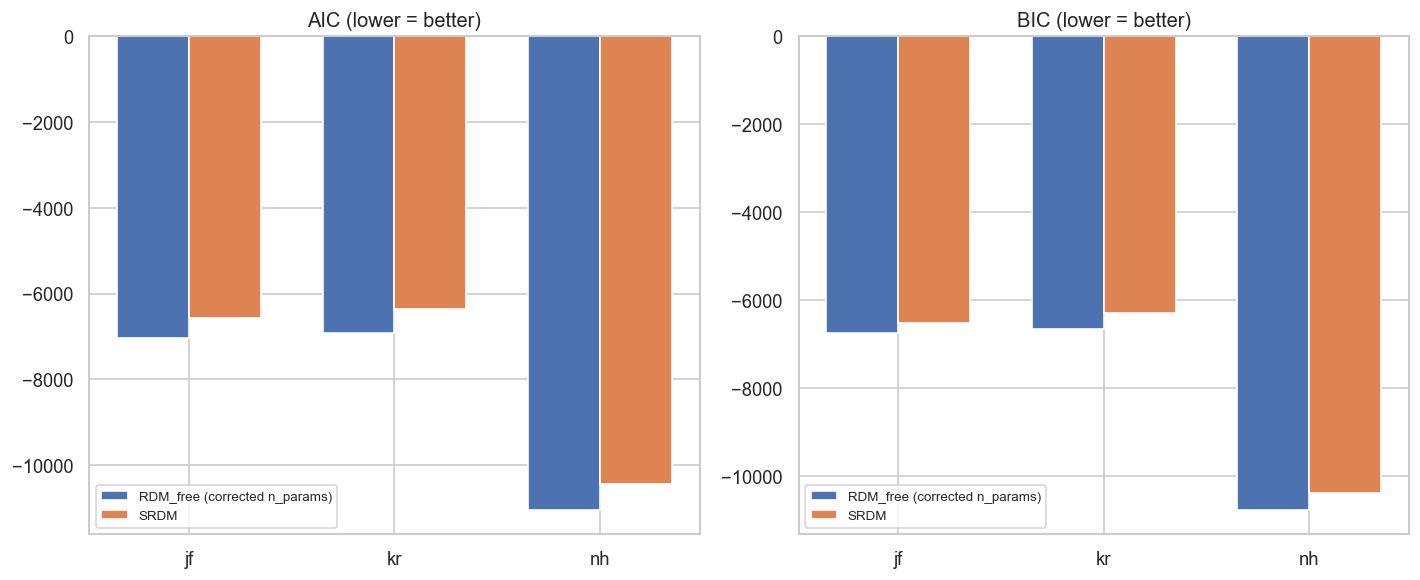


Summary (corrected):
pid  n_params_RDM_free  AIC_RDM_free      AIC_SRDM  dAIC (RDM-SRDM)  BIC_RDM_free      BIC_SRDM  dBIC (RDM-SRDM)
 jf                 40  -7024.264429  -6573.858692      -450.405737  -6749.107814  -6505.069538      -244.038276
 kr                 40  -6919.637746  -6363.511100      -556.126646  -6645.246166  -6294.913205      -350.332962
 nh                 40 -11053.729564 -10441.336096      -612.393467 -10774.724594 -10371.584854      -403.139740


In [49]:
# %% [markdown]
# # Compare RDM (free v/s per cell) against SRDM-implied v/s
#
# The SRDM's own generative structure already computes something
# equivalent to "v" and "s" (noise) internally, via its signal-detection
# front end: given d' and c per (difficulty x instruction) cell and a
# shared spike rate r, it derives
#     pk = Phi(d/2 - c),   pf = Phi(-d/2 - c)
#     vk = pk * r,         vf = pf * r
#     sigma_k = sqrt(pk*(1-pk)*r),   sigma_f = sqrt(pf*(1-pf)*r)
# (with a 0.05 floor on the sigmas, matching the Stan model).
#
# vk/sigma_k are the SRDM's implied "own-accumulator" drift/noise (i.e.
# the correct-accumulator analog), vf/sigma_f the "other-accumulator"
# (error-accumulator analog) -- directly comparable to RDM_free's own
# v_correct/s_correct and v_error/s_error, cell for cell.
#
# This is the B-and-t0-fixed, no-A version: B and t0 were fixed to
# SRDM's own fitted values when RDM_free was run, so they aren't free
# parameters in this output and aren't compared as if they were. A
# doesn't exist in this model version at all.
#
# NOTE: the n_params stored in fits_rdm_free_t0_noA.csv may not be
# trustworthy (this project has hit stale n_params formulas more than
# once). The correct count here is 4*N_CELLS (v_correct, v_error,
# s_correct, s_error, each sized N_CELLS; no A, no free t0, no B).
# This notebook recomputes AIC/BIC using that count rather than
# trusting the CSV's own value.

# %%
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

RDM_PATH = "fits_rdm_free_t0_noA.csv"
SRDM_PATH = "/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/NoLapse/fits_srdm_nolapse.csv"
N_LEVELS = 5            # resolution the RDM_free fit used
N_CELLS = 2 * N_LEVELS

PARTICIPANTS = ["jf", "kr", "nh"]
COLORS = {"jf": "tab:blue", "kr": "tab:orange", "nh": "tab:green"}
MARKERS = {"correct": "o", "error": "^"}

rdm = pd.read_csv(RDM_PATH).set_index("pid")
srdm_all = pd.read_csv(SRDM_PATH)
srdm = srdm_all[srdm_all["n_levels_actual"] == N_LEVELS].set_index("pid")

# %% [markdown]
# ## Fix AIC/BIC for RDM_free (recompute with the correct n_params)

# %%
def recompute_aic_bic(log_lik, n_trials, n_params):
    aic = 2 * n_params - 2 * log_lik
    bic = n_params * np.log(n_trials) - 2 * log_lik
    return aic, bic

RDM_N_PARAMS_CORRECT = 4 * N_CELLS  # v_correct, v_error, s_correct, s_error (each N_CELLS); B and t0 fixed

rows = []
for pid in PARTICIPANTS:
    r = rdm.loc[pid]
    aic_fixed, bic_fixed = recompute_aic_bic(r["log_lik_total"], r["n_trials"], RDM_N_PARAMS_CORRECT)
    rows.append(dict(
        pid=pid,
        n_params_stored=r["n_params"], n_params_correct=RDM_N_PARAMS_CORRECT,
        log_lik_RDM=r["log_lik_total"],
        AIC_RDM_stored=r["AIC"], AIC_RDM_correct=aic_fixed,
        BIC_RDM_stored=r["BIC"], BIC_RDM_correct=bic_fixed,
    ))
rdm_ic_fix = pd.DataFrame(rows).set_index("pid")
print(rdm_ic_fix)

# %% [markdown]
# ## Compute SRDM-implied v/s per (difficulty x instruction) cell

# %%
def srdm_implied_v_s(srdm_row, n_levels):
    """Returns (vk, vf, sigma_k, sigma_f) each length N_CELLS=2*n_levels,
    matching the SRDM Stan model's own transformed-parameters formulas."""
    n_cells = 2 * n_levels
    d_full = np.array([srdm_row[f"d_base[{ (i % n_levels) + 1 }]"] for i in range(n_cells)])
    c_by_sat = [srdm_row["c[1]"], srdm_row["c[2]"]]
    c_full = np.array([c_by_sat[0] if i < n_levels else c_by_sat[1] for i in range(n_cells)])
    r = srdm_row["r"]

    pk = norm.cdf(d_full/2 - c_full)
    pf = norm.cdf(-d_full/2 - c_full)
    vk = pk * r
    vf = pf * r
    sigma_k = np.maximum(np.sqrt(pk * (1-pk) * r), 0.05)
    sigma_f = np.maximum(np.sqrt(pf * (1-pf) * r), 0.05)
    return vk, vf, sigma_k, sigma_f

# %% [markdown]
# ## Build a long comparison table: one row per (pid, cell, accumulator type)

# %%
records = []
for pid in PARTICIPANTS:
    vk, vf, sigma_k, sigma_f = srdm_implied_v_s(srdm.loc[pid], N_LEVELS)
    r_row = rdm.loc[pid]

    v_correct_rdm = np.array([r_row[f"v_correct[{i}]"] for i in range(1, N_CELLS+1)])
    v_error_rdm   = np.array([r_row[f"v_error[{i}]"]   for i in range(1, N_CELLS+1)])
    s_correct_rdm = np.array([r_row[f"s_correct[{i}]"] for i in range(1, N_CELLS+1)])
    s_error_rdm   = np.array([r_row[f"s_error[{i}]"]   for i in range(1, N_CELLS+1)])

    for cell in range(N_CELLS):
        sat = "speed" if cell < N_LEVELS else "accuracy"
        level = (cell % N_LEVELS) + 1
        records.append(dict(pid=pid, cell=cell+1, sat=sat, level=level, accum="correct",
                             v_srdm=vk[cell], v_rdm=v_correct_rdm[cell],
                             s_srdm=sigma_k[cell], s_rdm=s_correct_rdm[cell]))
        records.append(dict(pid=pid, cell=cell+1, sat=sat, level=level, accum="error",
                             v_srdm=vf[cell], v_rdm=v_error_rdm[cell],
                             s_srdm=sigma_f[cell], s_rdm=s_error_rdm[cell]))

comp = pd.DataFrame(records)
comp["ratio_srdm"] = comp["v_srdm"] / comp["s_srdm"]
comp["ratio_rdm"] = comp["v_rdm"] / comp["s_rdm"]
comp.to_csv("rdm_vs_srdm_implied.csv", index=False)
comp.head(10)

# %% [markdown]
# ## Scatter: v (SRDM-implied vs. RDM freely-fitted)

# %%
fig, ax = plt.subplots(figsize=(6, 6))
for pid in PARTICIPANTS:
    for accum in ["correct", "error"]:
        sub = comp[(comp.pid == pid) & (comp.accum == accum)]
        ax.scatter(sub["v_srdm"], sub["v_rdm"], color=COLORS[pid], marker=MARKERS[accum],
                   alpha=0.8, label=f"{pid} ({accum})")
lims = [0, max(comp["v_srdm"].max(), comp["v_rdm"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("v implied from SRDM (d', c, r)")
ax.set_ylabel("v freely fitted in RDM_free")
ax.set_title("Drift rate: SRDM-implied vs. RDM freely-fitted")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("v_srdm_vs_rdm.png", dpi=150)
plt.show()

# %% [markdown]
# ## Scatter: s / noise (SRDM-implied vs. RDM freely-fitted)

# %%
fig, ax = plt.subplots(figsize=(6, 6))
for pid in PARTICIPANTS:
    for accum in ["correct", "error"]:
        sub = comp[(comp.pid == pid) & (comp.accum == accum)]
        ax.scatter(sub["s_srdm"], sub["s_rdm"], color=COLORS[pid], marker=MARKERS[accum],
                   alpha=0.8, label=f"{pid} ({accum})")
lims = [0, max(comp["s_srdm"].max(), comp["s_rdm"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("s (noise) implied from SRDM")
ax.set_ylabel("s freely fitted in RDM_free")
ax.set_title("Noise: SRDM-implied vs. RDM freely-fitted")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("s_srdm_vs_rdm.png", dpi=150)
plt.show()

# %% [markdown]
# ## Scatter: v/s ratio (SRDM-implied vs. RDM freely-fitted)

# %%
fig, ax = plt.subplots(figsize=(6, 6))
for pid in PARTICIPANTS:
    for accum in ["correct", "error"]:
        sub = comp[(comp.pid == pid) & (comp.accum == accum)]
        ax.scatter(sub["ratio_srdm"], sub["ratio_rdm"], color=COLORS[pid], marker=MARKERS[accum],
                   alpha=0.8, label=f"{pid} ({accum})")
lims = [0, max(comp["ratio_srdm"].max(), comp["ratio_rdm"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("v/s implied from SRDM")
ax.set_ylabel("v/s freely fitted in RDM_free")
ax.set_title("Signal-to-noise ratio (v/s): SRDM-implied vs. RDM freely-fitted")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("ratio_srdm_vs_rdm.png", dpi=150)
plt.show()

# %% [markdown]
# ## Other parameters: B, t0, r (all from SRDM)
#
# B and t0 were fixed to these same SRDM-fitted values when RDM_free was
# run, so there's no separate RDM-side value to compare them against --
# these are just shown for reference. A doesn't exist in this model.

# %%
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(PARTICIPANTS))

axes[0].bar(x - 0.2, [srdm.loc[p, "B"] for p in PARTICIPANTS], 0.4, label="B (fixed, from SRDM)")
axes[0].bar(x + 0.2, [srdm.loc[p, "t0"] for p in PARTICIPANTS], 0.4, label="t0 (fixed, from SRDM)")
axes[0].set_xticks(x); axes[0].set_xticklabels(PARTICIPANTS)
axes[0].set_title("Fixed inputs: B and t0")
axes[0].legend(fontsize=8)

axes[1].bar(x, [srdm.loc[p, "r"] for p in PARTICIPANTS], color=[COLORS[p] for p in PARTICIPANTS])
axes[1].set_xticks(x); axes[1].set_xticklabels(PARTICIPANTS)
axes[1].set_title("SRDM: r (spike rate)")

plt.tight_layout()
plt.savefig("other_params.png", dpi=150)
plt.show()

# %% [markdown]
# ## AIC / BIC comparison (using the corrected RDM_free parameter count)

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(PARTICIPANTS))
w = 0.35

aic_rdm = [rdm_ic_fix.loc[p, "AIC_RDM_correct"] for p in PARTICIPANTS]
aic_srdm = [srdm.loc[p, "AIC"] for p in PARTICIPANTS]
axes[0].bar(x - w/2, aic_rdm, w, label="RDM_free (corrected n_params)")
axes[0].bar(x + w/2, aic_srdm, w, label="SRDM")
axes[0].set_xticks(x); axes[0].set_xticklabels(PARTICIPANTS)
axes[0].set_title("AIC (lower = better)")
axes[0].legend(fontsize=8)

bic_rdm = [rdm_ic_fix.loc[p, "BIC_RDM_correct"] for p in PARTICIPANTS]
bic_srdm = [srdm.loc[p, "BIC"] for p in PARTICIPANTS]
axes[1].bar(x - w/2, bic_rdm, w, label="RDM_free (corrected n_params)")
axes[1].bar(x + w/2, bic_srdm, w, label="SRDM")
axes[1].set_xticks(x); axes[1].set_xticklabels(PARTICIPANTS)
axes[1].set_title("BIC (lower = better)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("aic_bic_comparison.png", dpi=150)
plt.show()

print("\nSummary (corrected):")
summary = pd.DataFrame({
    "pid": PARTICIPANTS,
    "n_params_RDM_free": RDM_N_PARAMS_CORRECT,
    "AIC_RDM_free": aic_rdm, "AIC_SRDM": aic_srdm,
    "dAIC (RDM-SRDM)": np.array(aic_rdm) - np.array(aic_srdm),
    "BIC_RDM_free": bic_rdm, "BIC_SRDM": bic_srdm,
    "dBIC (RDM-SRDM)": np.array(bic_rdm) - np.array(bic_srdm),
})
print(summary.to_string(index=False))

In [52]:
RDM_PATH = "fits_rdm_free_t0_noA.csv"

df_rdm = pd.read_csv(RDM_PATH)
df_rdm

,pid,n_levels_requested,n_levels_actual,n_params,n_trials,log_lik_total,AIC,BIC,fit_time_utc,lp__,...,s_error[1],s_error[2],s_error[3],s_error[4],s_error[5],s_error[6],s_error[7],s_error[8],s_error[9],s_error[10]
0,jf,5,5,40,7179,3552.132214,-7024.264429,-6749.107814,2026-07-29T21:07:27+00:00,3346.6493,...,2.718658,1.974731,2.071935,3.113865,3.159772,1.153668,1.820282,1.914639,1.696369,1.495328
1,kr,5,5,40,7043,3499.818873,-6919.637746,-6645.246166,2026-07-29T21:07:28+00:00,3366.6319,...,2.323732,1.863082,1.827277,2.172343,2.590798,1.071368,1.153893,1.281476,1.036008,1.092790
2,nh,5,5,40,7904,5566.864782,-11053.729564,-10774.724594,2026-07-29T21:07:29+00:00,5464.1056,...,2.270142,2.082060,1.666388,2.051283,2.413410,0.741037,1.665933,1.718134,1.347877,1.226597


In [53]:
SRDM_PATH = "/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/NoLapse/fits_srdm_nolapse.csv"
df_rdm = pd.read_csv(SRDM_PATH)
df_srdm

,pid,n_levels_requested,n_levels_actual,n_params,n_trials,log_lik_total,AIC,BIC,fit_time_utc,t0_hi,...,pf[45],pf[46],vk[45],vk[46],vf[45],vf[46],sigma_k[45],sigma_k[46],sigma_f[45],sigma_f[46]
0,jf,5,5,10,7179,3296.929346,-6573.858692,-6505.069538,2026-07-23T11:42:39+00:00,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,kr,5,5,10,7043,3191.755550,-6363.511100,-6294.913205,2026-07-23T11:42:56+00:00,0.208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nh,5,5,10,7904,5230.668048,-10441.336096,-10371.584854,2026-07-23T11:43:41+00:00,0.228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


1e-05
